<a href="https://colab.research.google.com/github/abdelrahman-rajab-hassan/unsupervised-ml-lab/blob/main/minor-projects/nhanes-diet-diabetes/nhanes_diet_diabetes_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Exercise Original Name: PCA_Exercise_(Core).ipynb
- Exercise Modified Name: nhanes_diet_diabetes_pca.ipynb

In [ ]:
# import necessary libraries
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# import sklearn library functions and classes
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

# import imblearn functions and classes
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_make_pipeline

# import the KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# import sklearn functions
from sklearn import set_config
set_config(transform_output = 'pandas')

# import custom functions
import my_utils as mu

In [ ]:
# create an original dataframe from the csv file to use for later comparison
data = pd.read_csv('NHANES_Diet_Diabetes_Risk.xls.csv')


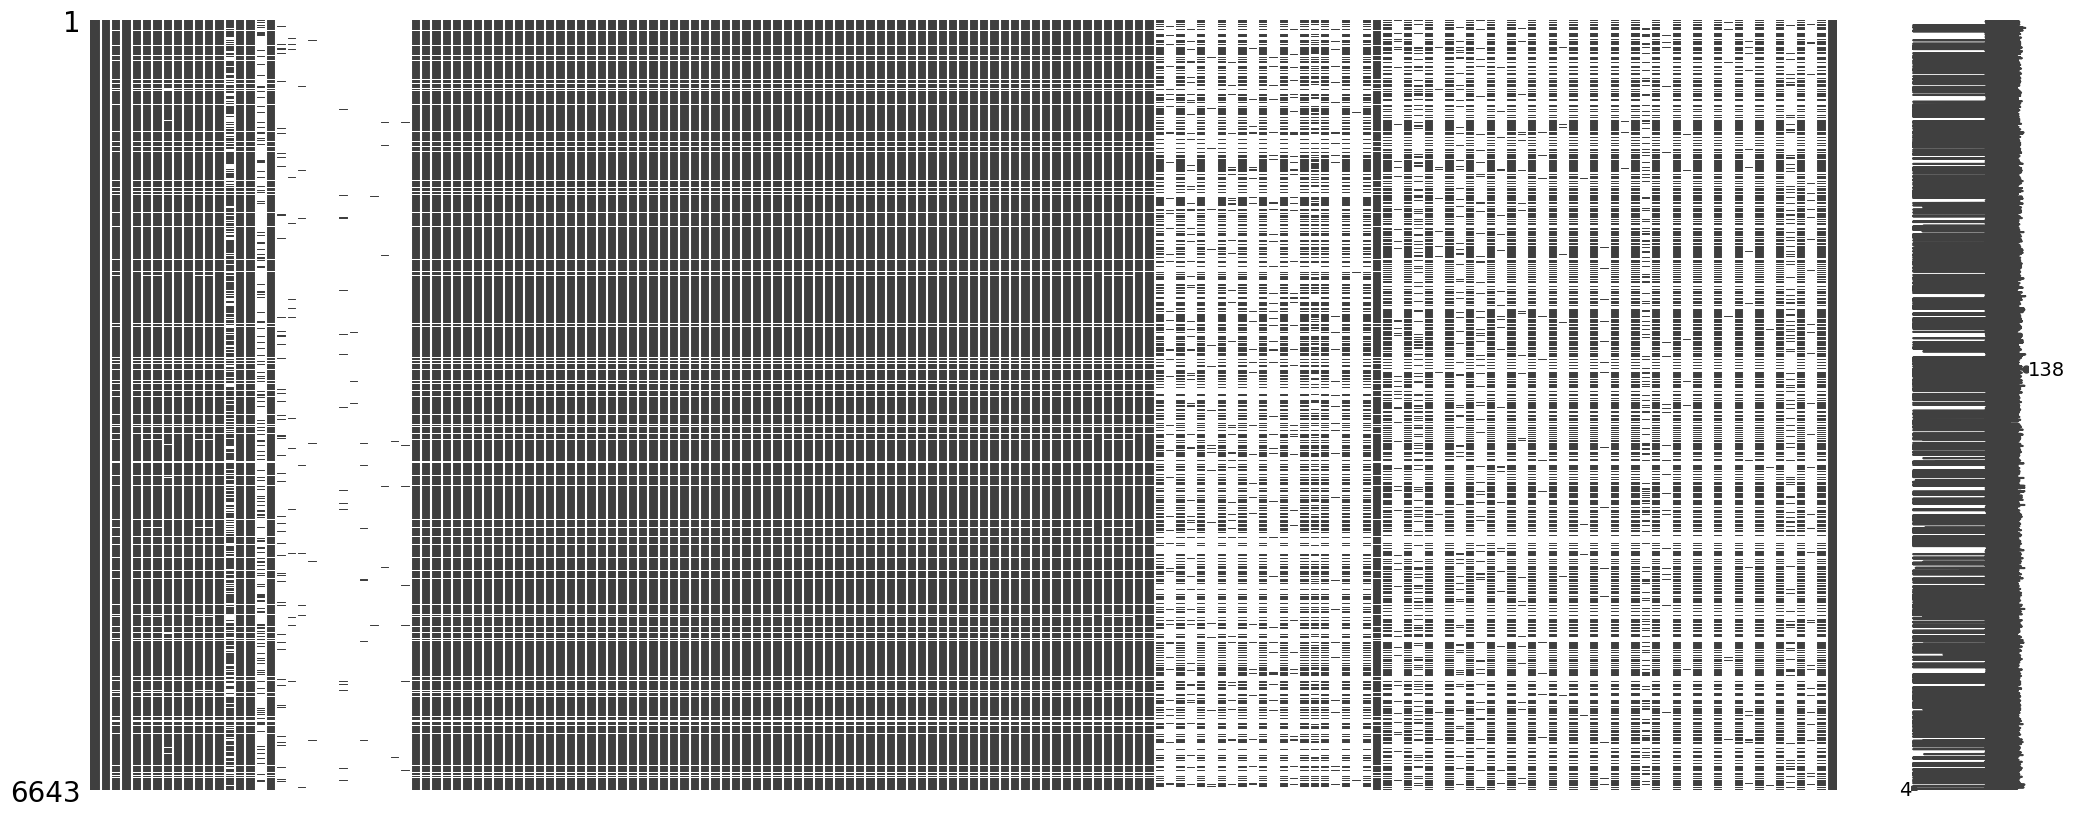

In [ ]:
# check for missing values in the original dataframe
import missingno as msno
msno.matrix(data);

In [ ]:
# create a copy of the original dataframe to use for the first model
df_original = data.copy()

# check the nummber of columns with missing values higher than 50%
(df_original.isnull().mean() > 0.5).sum()


np.int64(56)

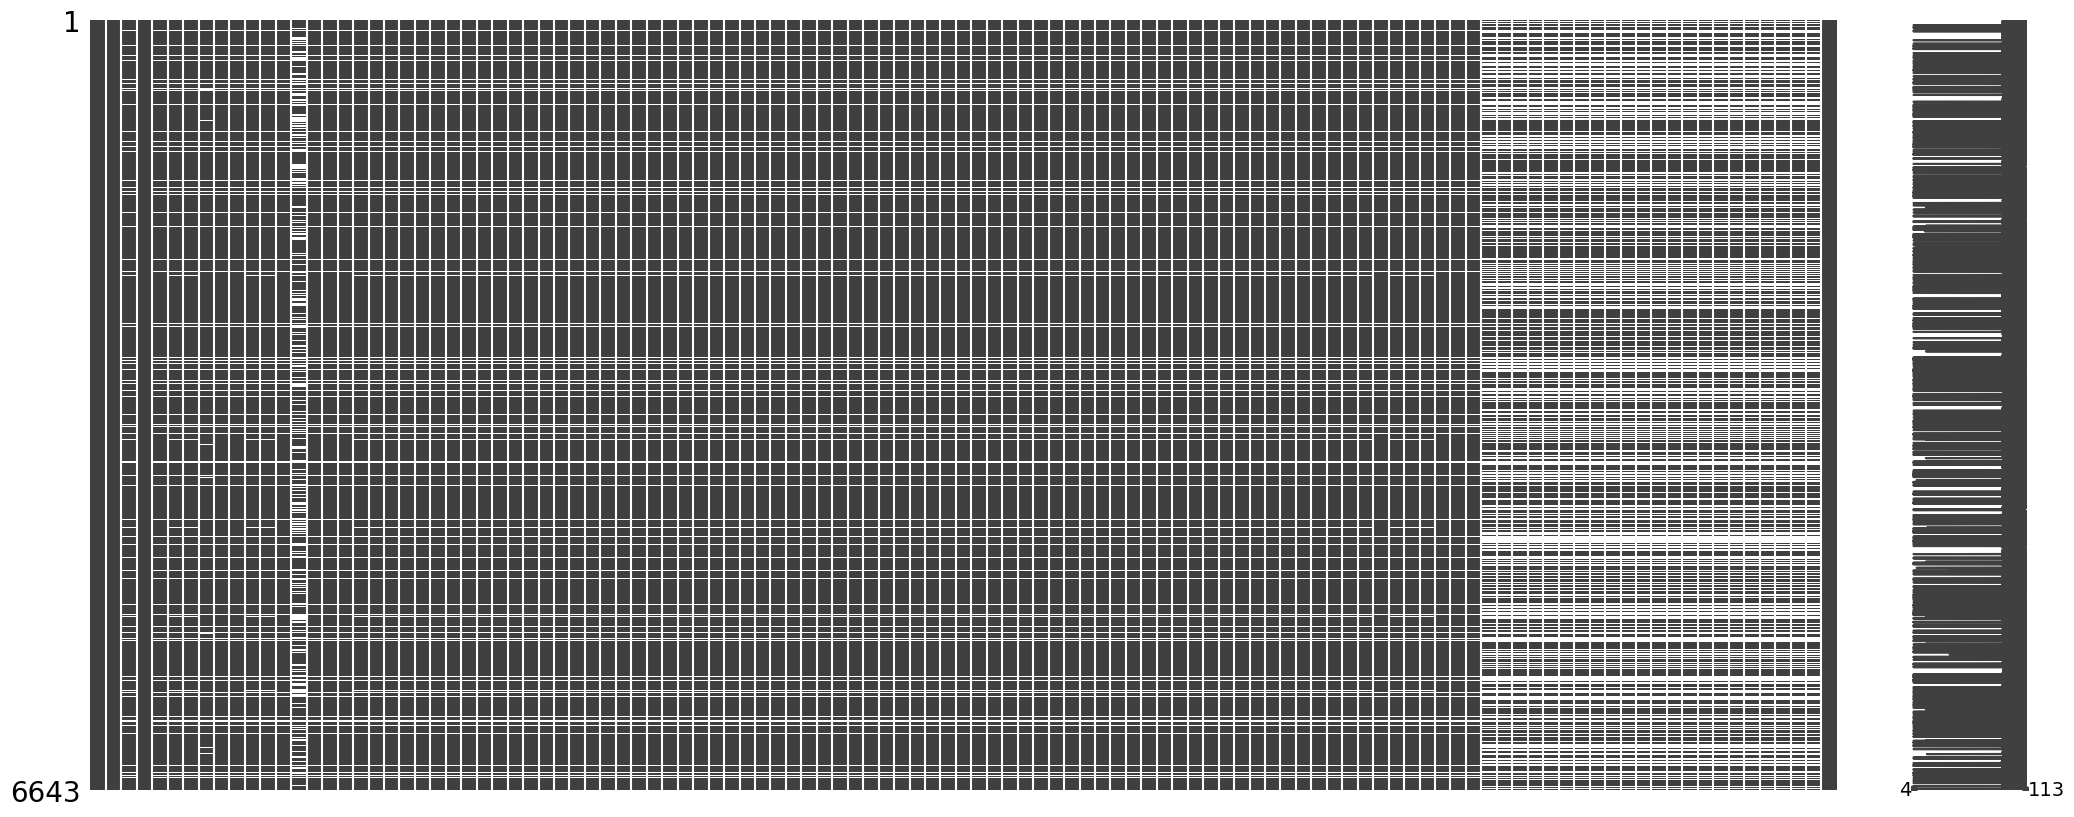

In [ ]:
# drop the columns with missing values higher than 50%
df_original = df_original.dropna(thresh = len(df_original) * 0.5, axis=1)

# re-check the matrix
msno.matrix(df_original);

# KNeighborsClassifier **`Without PCA`** — Benchmarking Model Speed

In [ ]:
# copy the df_original to a new df
df = df_original.copy() # if I was wrong just modify this to data.copy() so you can see the difference

# set SEQN as the index
df = df.set_index('SEQN')

# check the df
df.head()

,WTDRD1,WTDR2D,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,...,DRD370N,DRD370O,DRD370P,DRD370Q,DRD370R,DRD370S,DRD370T,DRD370U,DRD370V,Diabetes_Risk
SEQN,,,,,,,,,,,,,,,,,,,,,
73557,16888.32786,12930.89065,1,49.0,2.0,2.0,6.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
73558,17932.14387,12684.14887,1,59.0,2.0,2.0,4.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2
73559,59641.81293,39394.23671,1,49.0,2.0,2.0,18.0,6.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
73561,59052.35703,39004.89299,1,63.0,2.0,2.0,18.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0
73562,49890.82866,0.00000,1,49.0,2.0,1.0,11.0,3.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0


In [ ]:
# train test split the data

# y target variable
y = df['Diabetes_Risk']

X = df.drop('Diabetes_Risk', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# check for target class imbalance
y_train.value_counts()

Diabetes_Risk
0    4364
2     489
1     461
Name: count, dtype: int64

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.68      0.80      4364
           1       0.37      0.91      0.52       461
           2       0.40      0.90      0.55       489

    accuracy                           0.72      5314
   macro avg       0.58      0.83      0.63      5314
weighted avg       0.87      0.72      0.76      5314



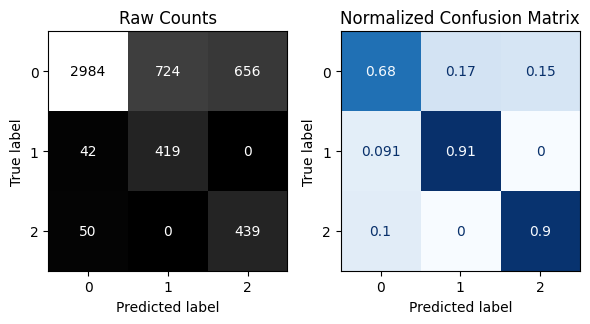


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.47      0.60      1088
           1       0.09      0.26      0.13       126
           2       0.09      0.25      0.13       115

    accuracy                           0.43      1329
   macro avg       0.33      0.33      0.29      1329
weighted avg       0.70      0.43      0.52      1329



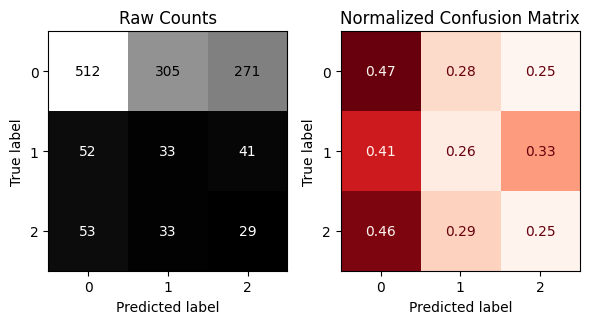

Time taken to fit the model: 0:00:00.425813


In [ ]:
# one-line model
non_pca = imb_make_pipeline(SimpleImputer(strategy = 'median'), StandardScaler(), SMOTE(), KNeighborsClassifier(n_neighbors = 3))

# start the timer
start = dt.datetime.now()

# fit the model
non_pca.fit(X_train, y_train)

# end the timer
end = dt.datetime.now()

# evaluate the model
mu.evaluate_classification(non_pca, X_train, y_train, X_test, y_test)

# print the time taken to fit the model
print('Time taken to fit the model:', end - start)


# KNeighborsClassifier **`With PCA`** — Benchmarking Model Speed

In [ ]:
# save a copy of the modified data
df = df_original.copy()

In [ ]:
# train test split the data

# y target variable
y = df['Diabetes_Risk']

X = df.drop('Diabetes_Risk', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.68      0.81      4364
           1       0.38      0.98      0.55       461
           2       0.42      0.97      0.58       489

    accuracy                           0.73      5314
   macro avg       0.60      0.88      0.65      5314
weighted avg       0.89      0.73      0.77      5314



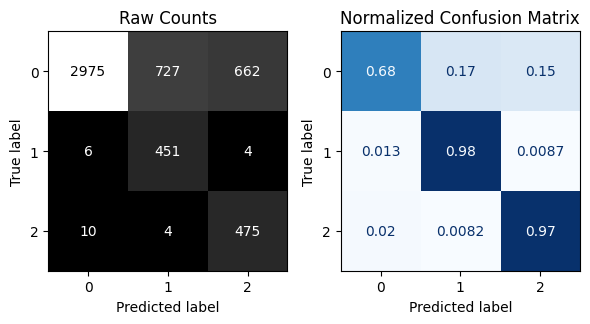


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.48      0.61      1088
           1       0.09      0.24      0.13       126
           2       0.09      0.28      0.14       115

    accuracy                           0.44      1329
   macro avg       0.34      0.33      0.29      1329
weighted avg       0.70      0.44      0.52      1329



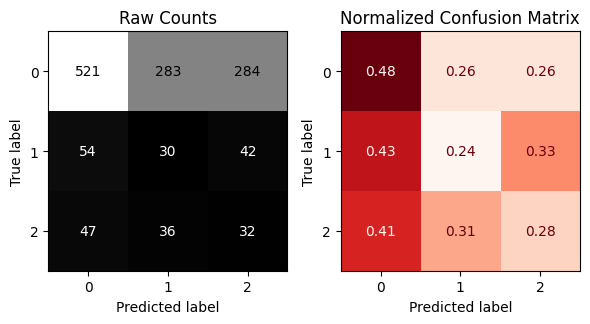

Number of components: 63
Time taken to fit the model: 0:00:00.188163


In [ ]:
# one-line model
with_pca = imb_make_pipeline(SimpleImputer(strategy = 'median'), StandardScaler(), SMOTE(), PCA(n_components = 0.95), KNeighborsClassifier(n_neighbors = 3))

# start the timer
start = dt.datetime.now()

# fit the model
with_pca.fit(X_train, y_train)

# end the timer
end = dt.datetime.now()

# evaluate the model
mu.evaluate_classification(with_pca, X_train, y_train, X_test, y_test)


# extract the pca_step
pca_step = with_pca.named_steps['pca'] # a simple way to extract any function or variable related to any step in the pipeline!!!

# print the num of principal components printed
print(f'Number of components: {pca_step.n_components_}')

# print the time taken to fit the model
print('Time taken to fit the model:', end - start)
#

## **Key insights**

### 🔢 How many features were used in each model?
| Model | Features Used |
|---|---|
| Without PCA | 113 original columns |
| With PCA | 63 principal components |

---

### 🏆 Which model performed best on the test set?
Both models performed **almost identically** — the difference across all metrics was less than 1%, meaning PCA retained virtually all the predictive power of the original features.

---

### ⚡ Which model was the fastest at making predictions?
The **PCA model** was faster, since it operates on 63 components instead of 113 features — fewer dimensions means less computation at prediction time.